In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    LeaveOneGroupOut,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.svm import SVC
from tools import compute_PCA, compute_TSNE, load_data

# Support Vector Machine (SVM)

In [2]:
X, T, F, A, P = load_data([ps for ps in range(1, 16)], z_score_norm=None)
X = X.reshape(X.shape[0], X.shape[1] * X.shape[1])

load: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15']


$$\mathbf{X} \rightarrow \mathrm{EIT}$$
$$A \rightarrow \mathrm{Angle}$$
$$T \rightarrow \mathrm{Torque}$$
$$F \rightarrow \mathrm{Force}$$

In [3]:
def indices_with_tolerance(arr, target, tol):
    """
    A ... angle/position or Force or Torque
    target ... target angle
    tol ... +/- tolerance
    """
    arr = np.asarray(arr)
    detected = np.where(np.abs(arr - target) <= tol)[0]
    print(f"Found {len(detected):,} for position {target} and a tolerance of {tol}.")
    return detected

In [4]:
param_grid = [
    {"svm__kernel": ["linear"], "svm__C": [0.01, 0.1, 1, 10, 100]},
    {
        "svm__kernel": ["rbf"],
        "svm__C": [100],
        "svm__gamma": ["scale", "auto", 0.01, 0.1, 1],
    },
    {
        "svm__kernel": ["sigmoid"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": ["scale", "auto", 0.01, 0.1, 1],
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.01, 0.1, 1, 10],
        "svm__degree": [2, 3, 4],
        "svm__gamma": ["scale", "auto"],
    },
]

## Mapping: $\mathbf{X} \rightarrow A|_{\mathrm{targets}}$

In [5]:
p1s = indices_with_tolerance(A, 25, tol=1)  # Adjustment place
p2s = indices_with_tolerance(A, 50, tol=1)  # Adjustment place
p3s = indices_with_tolerance(A, 75, tol=1)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$1°", r"50$\pm$1°", r"75$\pm$1°"]  # Adjustment place
np.random.shuffle(targets)

Found 1,049 for position 25 and a tolerance of 1.
Found 1,041 for position 50 and a tolerance of 1.
Found 1,052 for position 75 and a tolerance of 1.


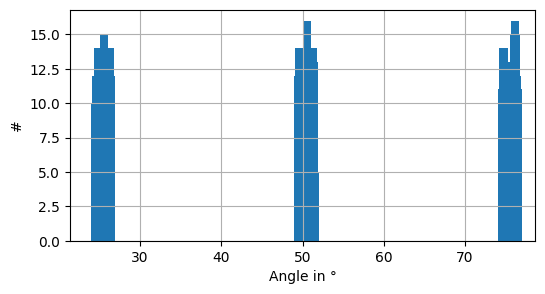

In [6]:
plt.figure(figsize=(6, 3))
plt.hist(A[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Angle in °")  # Adjustment place
plt.show()

In [7]:
y = A[targets]  # A -> Angle # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [8]:
params_path = "params/TrainValid_A_SVM.pkl"  # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Fitting 5 folds for each of 59 candidates, totalling 295 fits
Beste CV-Accuracy: 0.9455672232742296
beste parameter: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}


In [9]:
best_model = SVC(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.5657
Fold 2 Balanced Accuracy: 0.5276
Fold 3 Balanced Accuracy: 0.5254
Fold 4 Balanced Accuracy: 0.5289
Fold 5 Balanced Accuracy: 0.5448

Mean Balanced Accuracy: 0.5384962406015037
Std Balanced Accuracy: 0.01523389680705339

accuracy_score: 0.5385105028644176
balanced_accuracy_score: 0.5384942073681985
r2_score: -0.15608609448492805



Classification Report:
              precision    recall  f1-score   support

         0.0       0.57      0.64      0.60      1047
         1.0       0.46      0.39      0.42      1047
         2.0       0.57      0.59      0.58      1048

    accuracy                           0.54      3142
   macro avg       0.53      0.54      0.53      3142
weighted avg       0.53      0.54      0.53      3142



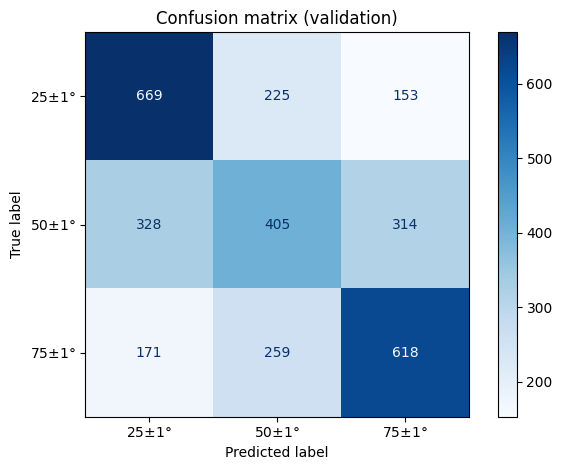

In [10]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_A_SVM.pdf")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [11]:
params_path = "params/TrainTest_A_SVM.pkl"  # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])  # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Fitting 5 folds for each of 59 candidates, totalling 295 fits
Best CV-Accuracy: 0.3567611488139672
Best parameter: {'C': 0.1, 'kernel': 'linear'}


In [12]:
best_model = SVC(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3580
Fold 2 Accuracy: 0.3413
Fold 3 Accuracy: 0.3343
Fold 4 Accuracy: 0.4120
Fold 5 Accuracy: 0.3344

Mean Accuracy: 0.35599387385857806
Std Accuracy: 0.029293871827075418

accuracy_score 0.35614258434118395
balanced_accuracy_score 0.35616057996796857



Classification Report:
              precision    recall  f1-score   support

         0.0       0.36      0.60      0.45      1047
         1.0       0.33      0.17      0.23      1047
         2.0       0.37      0.30      0.33      1048

    accuracy                           0.36      3142
   macro avg       0.35      0.36      0.34      3142
weighted avg       0.35      0.36      0.34      3142



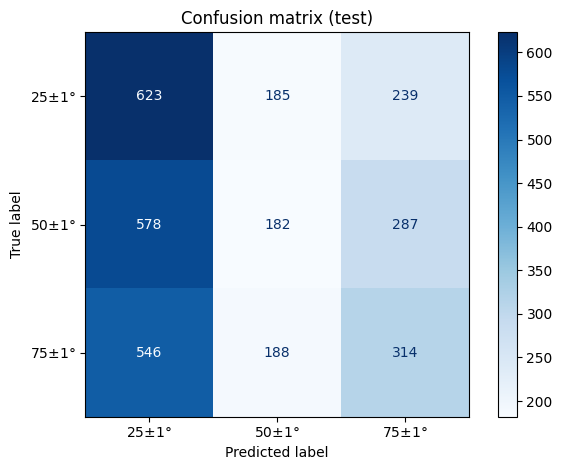

In [13]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_A_SVM.pdf")  # Adjustment place
plt.show()

## Mapping: $\mathbf{X} \rightarrow T|_{\mathrm{targets}}$

In [14]:
p1s = indices_with_tolerance(T, 30, tol=1)  # Adjustment place
p2s = indices_with_tolerance(T, 50, tol=1)  # Adjustment place
p3s = indices_with_tolerance(T, 70, tol=1)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"50$\pm$20Nm", r"125$\pm$20Nm", r"200$\pm$20Nm"]  # Adjustment place
np.random.shuffle(targets)

Found 2,523 for position 30 and a tolerance of 1.
Found 1,953 for position 50 and a tolerance of 1.
Found 1,249 for position 70 and a tolerance of 1.


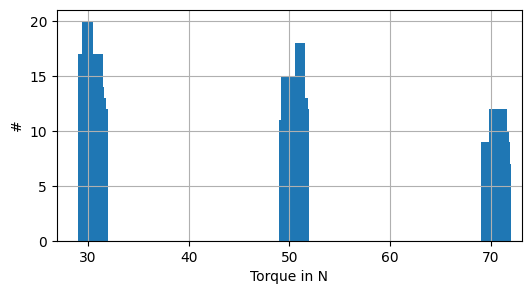

In [15]:
plt.figure(figsize=(6, 3))
plt.hist(T[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Torque in N")  # Adjustment place
plt.show()

In [16]:
y = T[targets]  # T -> Torque # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [17]:
params_path = "params/TrainValid_T_SVM.pkl"  # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Fitting 5 folds for each of 59 candidates, totalling 295 fits
Beste CV-Accuracy: 0.7678602620087336
beste parameter: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}


In [18]:
best_model = SVC(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.6796
Fold 2 Balanced Accuracy: 0.6866
Fold 3 Balanced Accuracy: 0.6909
Fold 4 Balanced Accuracy: 0.7082
Fold 5 Balanced Accuracy: 0.6994

Mean Balanced Accuracy: 0.6929216308694398
Std Balanced Accuracy: 0.009982644254248385

accuracy_score: 0.6929257641921397
balanced_accuracy_score: 0.6929224509010429
r2_score: 0.41210371949454905



Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.81      0.76      1908
         1.0       0.59      0.56      0.57      1908
         2.0       0.78      0.71      0.74      1909

    accuracy                           0.69      5725
   macro avg       0.69      0.69      0.69      5725
weighted avg       0.69      0.69      0.69      5725



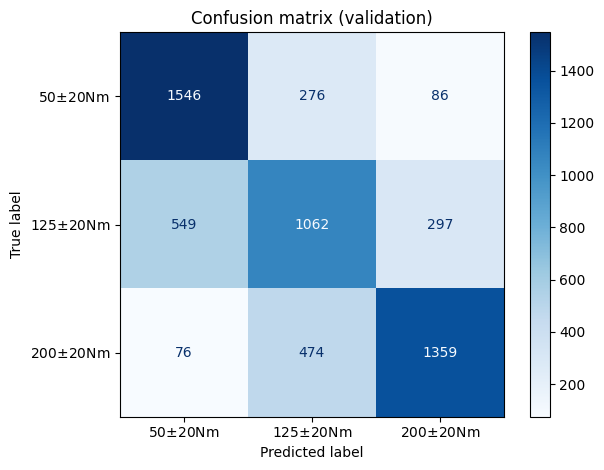

In [19]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_T_SVM.pdf")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [20]:
params_path = "params/TrainTest_T_SVM.pkl"  # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])  # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Fitting 5 folds for each of 59 candidates, totalling 295 fits
Best CV-Accuracy: 0.3828501021263286
Best parameter: {'C': 0.1, 'kernel': 'linear'}


In [21]:
best_model = SVC(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3088
Fold 2 Accuracy: 0.3460
Fold 3 Accuracy: 0.3320
Fold 4 Accuracy: 0.3453
Fold 5 Accuracy: 0.3214

Mean Accuracy: 0.33071336171595467
Std Accuracy: 0.014236630111831808

accuracy_score 0.34358078602620085
balanced_accuracy_score 0.3435657679482857



Classification Report:
              precision    recall  f1-score   support

         0.0       0.34      0.43      0.38      1908
         1.0       0.32      0.17      0.23      1908
         2.0       0.36      0.43      0.39      1909

    accuracy                           0.34      5725
   macro avg       0.34      0.34      0.33      5725
weighted avg       0.34      0.34      0.33      5725



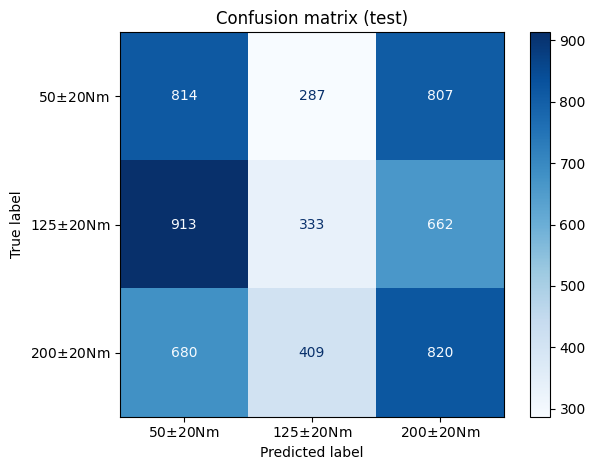

In [22]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_T_SVM.pdf")  # Adjustment place
plt.show()

## Mapping: $\mathbf{X} \rightarrow F|_{\mathrm{targets}}$

In [23]:
p1s = indices_with_tolerance(F, 50, tol=2)  # Adjustment place
p2s = indices_with_tolerance(F, 125, tol=2)  # Adjustment place
p3s = indices_with_tolerance(F, 200, tol=2)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$N", r"100$\pm$N", r"175$\pm$N"]  # Adjustment place
np.random.shuffle(targets)

Found 1,208 for position 50 and a tolerance of 2.
Found 1,545 for position 125 and a tolerance of 2.
Found 901 for position 200 and a tolerance of 2.


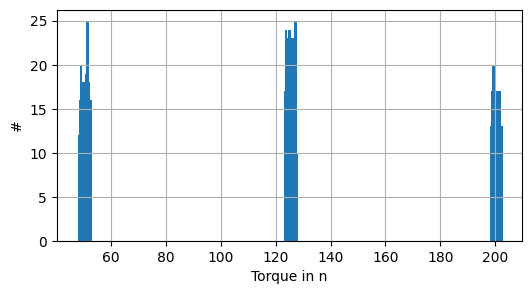

In [24]:
plt.figure(figsize=(6, 3))
plt.hist(F[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Torque in n")
plt.show()

In [25]:
y = F[targets]  # F -> Force # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [26]:
params_path = "params/TrainValid_F_SVM.pkl"  # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Fitting 5 folds for each of 59 candidates, totalling 295 fits
Beste CV-Accuracy: 0.8114378876749807
beste parameter: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}


In [27]:
best_model = SVC(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.6375
Fold 2 Balanced Accuracy: 0.6896
Fold 3 Balanced Accuracy: 0.6362
Fold 4 Balanced Accuracy: 0.6388
Fold 5 Balanced Accuracy: 0.6739

Mean Balanced Accuracy: 0.6551980031032855
Std Balanced Accuracy: 0.022264681913598882

accuracy_score: 0.6551724137931034
balanced_accuracy_score: 0.6551724137931035
r2_score: 0.08004926108374388



Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.63      0.66      1218
         1.0       0.59      0.74      0.66      1218
         2.0       0.70      0.59      0.64      1218

    accuracy                           0.66      3654
   macro avg       0.66      0.66      0.65      3654
weighted avg       0.66      0.66      0.65      3654



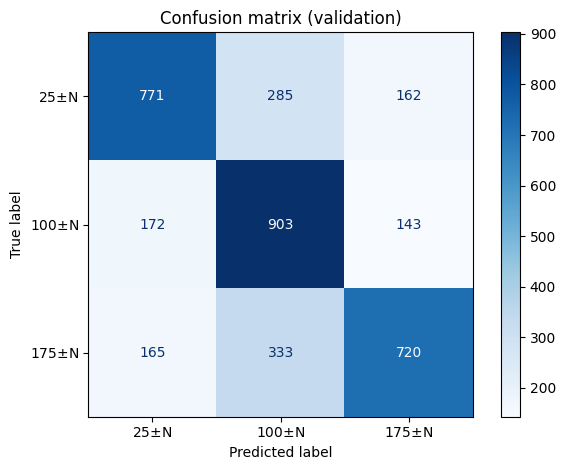

In [28]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_F_SVM.pdf")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [29]:
params_path = "params/TrainTest_F_SVM.pkl"  # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])  # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Fitting 5 folds for each of 59 candidates, totalling 295 fits
Best CV-Accuracy: 0.4035699441401504
Best parameter: {'C': 100, 'gamma': 0.1, 'kernel': 'sigmoid'}


In [30]:
best_model = SVC(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3116
Fold 2 Accuracy: 0.3377
Fold 3 Accuracy: 0.3333
Fold 4 Accuracy: 0.3809
Fold 5 Accuracy: 0.3755

Mean Accuracy: 0.34781116057465145
Std Accuracy: 0.026376553385951265

accuracy_score 0.3576902025177887
balanced_accuracy_score 0.35769020251778877



Classification Report:
              precision    recall  f1-score   support

         0.0       0.38      0.57      0.45      1218
         1.0       0.48      0.02      0.05      1218
         2.0       0.33      0.48      0.39      1218

    accuracy                           0.36      3654
   macro avg       0.40      0.36      0.30      3654
weighted avg       0.40      0.36      0.30      3654



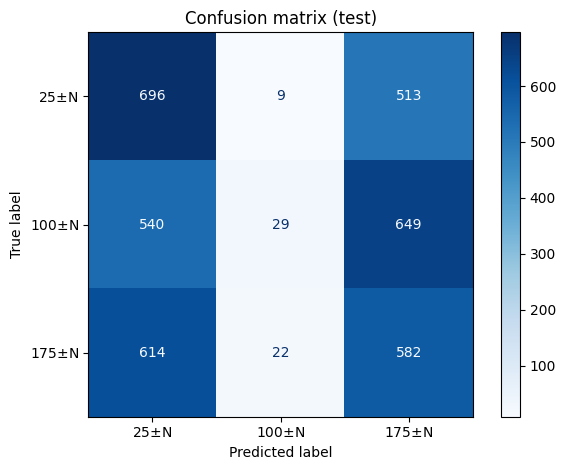

In [31]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_F_SVM.pdf")  # Adjustment place
plt.show()

___